In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer,InputExample,losses,util
from sentence_transformers.evaluation import InformationRetrievalEvaluator  # type: ignore
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error,classification_report
from sklearn.metrics.pairwise import cosine_similarity
import json, warnings
warnings.filterwarnings("ignore")

/var/folders/sc/r00qn7g96s95hmmhkr9v8x080000gn/T/ipykernel_9051/3662582425.py:6: DeprecationWarning: Importing from 'sentence_transformers.evaluation' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.evaluation' instead.
  from sentence_transformers.evaluation import InformationRetrievalEvaluator


In [3]:
df = pd.read_csv('cleaned_resumeJD_pairs.csv')
print(f'Loaded: {len(df)} pairs')
print(f'\nLabel distribution:')
print(df['match_label'].value_counts())
print(f'\nScore range: {df["match_score"].min()} - {df["match_score"].max()}')
df.head(3)

Loaded: 280 pairs

Label distribution:
match_label
medium    110
high       93
low        77
Name: count, dtype: int64

Score range: 0.06 - 0.94


,resume_text,job_description,match_label,match_score,match_label_lower,resume_len,jd_len
0,BI Analyst with 7 years of experience based in...,Fathom is hiring a Financial Analyst (Berlin)....,medium,0.53,medium,75,71
1,Data Scientist with 13 years of experience bas...,Lumen is hiring a Senior UX Designer (Singapor...,low,0.26,low,79,74
2,Software Engineer with 8 years of experience b...,Acme Corp is hiring a Product Manager (Seattle...,low,0.31,low,71,80


In [4]:
train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['match_label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['match_label']
)

print(f'Train:       {len(train_df)} pairs')
print(f'Validation:  {len(val_df)} pairs')
print(f'Test:        {len(test_df)} pairs')
print()

# Verify each split has all 3 labels
for name, split in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    print(f'{name} label dist: {split["match_label"].value_counts().to_dict()}')

Train:       196 pairs
Validation:  42 pairs
Test:        42 pairs

Train label dist: {'medium': 77, 'high': 65, 'low': 54}
Validation label dist: {'medium': 16, 'high': 14, 'low': 12}
Test label dist: {'medium': 17, 'high': 14, 'low': 11}


In [5]:
# Convert to InputExample format - sentence-transformers
# text1 = resume, text2 = job description, label = score

# Normalize column names in train_df and val_df to handle potential whitespace issues
train_df.columns = train_df.columns.str.strip()
val_df.columns = val_df.columns.str.strip()

# Print columns to debug KeyError
print(f"Train DataFrame columns: {train_df.columns.tolist()}")
print(f"Validation DataFrame columns: {val_df.columns.tolist()}")

train_examples = [InputExample(texts=[row['resume_text'], row['job_description']], label=float(row['match_score']))
    for _, row in train_df.iterrows()
]

val_examples = [
    InputExample(texts=[row['resume_text'], row['job_description']], label=float(row['match_score']))
    for _, row in val_df.iterrows()
]

print(f'Train examples: {len(train_examples)}')
print(f'Val examples:   {len(val_examples)}')
print(f'\nSample InputExample:')
print(f'  text1 (resume): {train_examples[0].texts[0][:80]}...')
print(f'  text2 (JD):     {train_examples[0].texts[1][:80]}...')
print(f'  label:          {train_examples[0].label}')

Train DataFrame columns: ['resume_text', 'job_description', 'match_label', 'match_score', 'match_label_lower', 'resume_len', 'jd_len']
Validation DataFrame columns: ['resume_text', 'job_description', 'match_label', 'match_score', 'match_label_lower', 'resume_len', 'jd_len']
Train examples: 196
Val examples:   42

Sample InputExample:
  text1 (resume): Site Reliability Engineer with 6 years of experience based in Toronto. M.S. in H...
  text2 (JD):     TechNova is hiring a Associate Product Manager (Seattle). In this role you will ...
  label:          0.15


In [6]:
print('laoding base bert model')
base_model = SentenceTransformer('all-mpnet-base-v2')

laoding base bert model


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [7]:
# Evaluate base model on test set BEFORE fine-tuning
# This is our baseline, fine-tuning should beat this
print('Evaluating base model on test set...')

base_preds = []
for _, row in test_df.iterrows():
    emb1 = base_model.encode(row['resume_text'])
    emb2 = base_model.encode(row['job_description'])
    sim = cosine_similarity([emb1], [emb2])[0][0]
    base_preds.append(float(sim))

base_mae = mean_absolute_error(test_df['match_score'], base_preds)
base_rmse = np.sqrt(mean_squared_error(test_df['match_score'], base_preds))

print(f'\nBase Model - Test Set Performance')
print(f'  MAE:  {base_mae:.4f}')
print(f'  RMSE: {base_rmse:.4f}')
print()
print('Goal: fine-tuning should reduce MAE below baseline')

Evaluating base model on test set...

Base Model - Test Set Performance
  MAE:  0.1946
  RMSE: 0.2332

Goal: fine-tuning should reduce MAE below baseline


In [10]:
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator # type: ignore
model = SentenceTransformer('all-mpnet-base-v2')
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)
train_loss = losses.CosineSimilarityLoss(model=model)

evaluator = EmbeddingSimilarityEvaluator.from_input_examples(
    val_examples, name='ats-val'
)

print('Training setup ready.')
print(f'  Batch size:  16')
print(f'  Train pairs: {len(train_examples)}')
print(f'  Steps/epoch: {len(train_dataloader)}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Training setup ready.
  Batch size:  16
  Train pairs: 196
  Steps/epoch: 13


In [11]:
total_steps  = len(train_dataloader) * 10
warmup_steps = int(total_steps * 0.1)

print(f'Total steps:  {total_steps}')
print(f'Warmup steps: {warmup_steps}')
print(f'\nStarting fine-tuning...\n')

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    evaluator=evaluator,
    epochs=10,
    evaluation_steps=len(train_dataloader),
    warmup_steps=warmup_steps,
    output_path='models/finetuned-bert',
    save_best_model=True,
    show_progress_bar=True
)

Total steps:  130
Warmup steps: 13

Starting fine-tuning...



ImportError: Please install `datasets` to use this function: `pip install datasets`.

In [ ]:
finetuned_model = SentenceTransformer('models/finetuned-bert')
print('Fine-tuned model loaded.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fine-tuned model loaded.


In [ ]:
ft_preds = []
for _, row in test_df.iterrows():
    emb1 = finetuned_model.encode(row['resume_text'])
    emb2 = finetuned_model.encode(row['job_description'])
    sim = cosine_similarity([emb1], [emb2])[0][0]
    ft_preds.append(float(sim))

ft_mae = mean_absolute_error(test_df['match_score'], ft_preds)
ft_rmse = np.sqrt(mean_squared_error(test_df['match_score'], ft_preds))

print(f'\nFine-tuned Model - Test Set Performance')
print(f'  MAE:  {ft_mae:.4f}')
print(f'  RMSE: {ft_rmse:.4f}')


Fine-tuned Model - Test Set Performance
  MAE:  0.0986
  RMSE: 0.1217


In [ ]:
print('MODEL COMPARISON')
print(f'  Base MAE:       {base_mae:.4f}')
print(f'  Fine-tuned MAE: {ft_mae:.4f}')
print(f'  Improvement:    {(base_mae - ft_mae) / base_mae * 100:.1f}%')

MODEL COMPARISON
  Base MAE:       0.1946
  Fine-tuned MAE: 0.0986
  Improvement:    49.3%


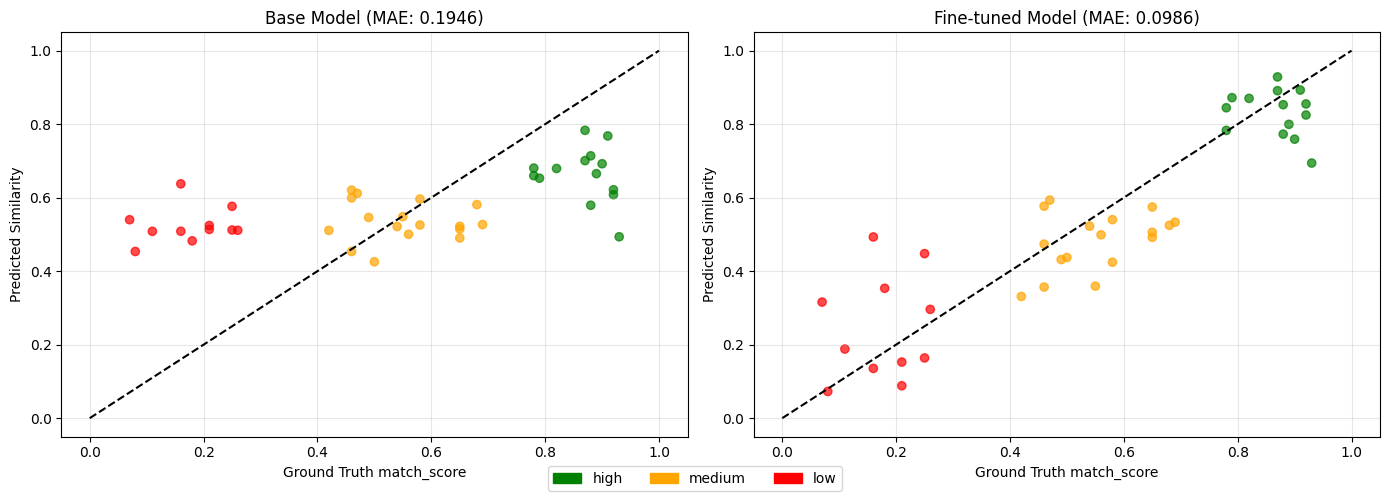

In [ ]:
# Scatter plots: base vs fine-tuned
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = test_df['match_label'].map({'low': 'red', 'medium': 'orange', 'high': 'green'})

for ax, preds, title, mae in [
    (axes[0], base_preds, 'Base Model', base_mae),
    (axes[1], ft_preds, 'Fine-tuned Model', ft_mae)
]:
    ax.scatter(test_df['match_score'], preds, c=colors, alpha=0.7)
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect Fit')
    ax.set_xlabel('Ground Truth match_score')
    ax.set_ylabel('Predicted Similarity')
    ax.set_title(f'{title} (MAE: {mae:.4f})')
    ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(color='green', label='high'),
    Patch(color='orange', label='medium'),
    Patch(color='red', label='low'),
], loc='lower center', ncol=3)
plt.tight_layout()

In [ ]:
metadata = {
    'base_model': 'all-mpnet-base-v2',
    'dataset': 'merged_dataset_clean.csv',
    'total_pairs': len(df),
    'train_pairs': len(train_df),
    'val_pairs': len(val_df),
    'test_pairs': len(test_df),
    'epochs': 10,
    'batch_size': 16,
    'base_mae': round(float(base_mae), 4),
    'finetuned_mae': round(float(ft_mae), 4),
    'improvement_pct': round((base_mae - ft_mae) / base_mae * 100, 1)
}

with open('models/finetuned-bert/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: models/finetuned-bert/')
print(json.dumps(metadata, indent=2))

Saved: models/finetuned-bert/
{
  "base_model": "all-mpnet-base-v2",
  "dataset": "merged_dataset_clean.csv",
  "total_pairs": 280,
  "train_pairs": 196,
  "val_pairs": 42,
  "test_pairs": 42,
  "epochs": 10,
  "batch_size": 16,
  "base_mae": 0.1946,
  "finetuned_mae": 0.0986,
  "improvement_pct": 49.3
}


In [ ]:
def predict_match(resume_text, jd_text):
    emb_resume = finetuned_model.encode(resume_text)
    emb_jd = finetuned_model.encode(jd_text)
    score = cosine_similarity([emb_resume], [emb_jd])[0][0]

    if score >= 0.7:
        label = "HIGH"
    elif score >= 0.4:
        label = "MEDIUM"
    else:
        label = "LOW"

    return float(score), label


# Test cases
test_cases = [
    {
        'label': 'HIGH match expected',
        'resume': 'Senior Python developer with 6 years experience in Django...',
        'jd': 'We need a Python developer proficient in Django and API...'
    },
    {
        'label': 'MEDIUM match expected',
        'resume': 'Frontend developer with React experience...',
        'jd': 'Full stack engineer required with Node.js and React...'
    },
    {
        'label': 'LOW match expected',
        'resume': 'Graphic designer with Photoshop and Illustrator skills...',
        'jd': 'Data Scientist with Python, ML, and SQL experience required...'
    }
]

print("Production Pipeline Test")
print("=" * 50)
print()

for case in test_cases:
    score, category = predict_match(case['resume'], case['jd'])
    print(case['label'])
    print(f"  Predicted score: {score:.4f}  ->  {category}")
    print()

Production Pipeline Test

HIGH match expected
  Predicted score: 0.7929  ->  HIGH

MEDIUM match expected
  Predicted score: 0.7258  ->  HIGH

LOW match expected
  Predicted score: 0.2699  ->  LOW

